In [1]:
import utils

import os
from pathlib import Path
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import e, m_p
import pandas as pd

import xtrack as xt
import xpart as xp
import xobjects as xo
import xfields as xf
import xwakes as xw

from cpymad.madx import Madx
from PyHEADTAIL.particles import Particles
import nafflib

PyHEADTAIL v1.16.5


# Without space charge

In [2]:
name = 'hyper_no_sc_200'

with h5py.File(f'data/{name}.h5', 'r') as f:
    n_particles = f.attrs['n_particles']
    nemitt_x_0 = f.attrs['nemitt_x_0']
    nemitt_y_0 = f.attrs['nemitt_y_0']
    
    gamma = f.attrs['gamma']
    beta = f.attrs['beta']
    
    qx = f.attrs['qx']
    qy = f.attrs['qy']
    dqx = f.attrs['dqx']
    dqy = f.attrs['dqy']
    
    x_tbt = f['x_tbt'][:]
    y_tbt = f['y_tbt'][:]
    px_tbt = f['px_tbt'][:]
    py_tbt = f['py_tbt'][:]

    twiss = f['twiss_data']
    
df_twiss = pd.read_hdf(f'data/{name}.h5', key='twiss_data')

betx = df_twiss['betx'].values
bety = df_twiss['bety'].values
alfx = df_twiss['alfx'].values
alfy = df_twiss['alfy'].values

/home/rsimpson/anaconda3/envs/Xtrack/lib/python3.13/site-packages/tables/attributeset.py:322: DataTypeWarning: Unsupported type for attribute 'thick' in node '/'. Offending HDF5 class: 8
  value = self._g_getattr(self._v_node, name)


In [3]:
Qx = utils.get_tune(x_tbt, px_tbt, betx[0], alfx[0])
Qy = utils.get_tune(y_tbt, py_tbt, bety[0], alfy[0])

Qy = abs(Qy)
for i in range(len(Qy)):
    if Qy[i]>0.2:
        qy[i] = qy[i]/2
        
Qy = 1-Qy

nemitt_x_tbt = utils.calculate_emittance_tbt(x_tbt, px_tbt, beta, gamma)
nemitt_y_tbt = utils.calculate_emittance_tbt(y_tbt, py_tbt, beta, gamma)

Text(0.5, 1.0, 'Fractional Tune Footprint')

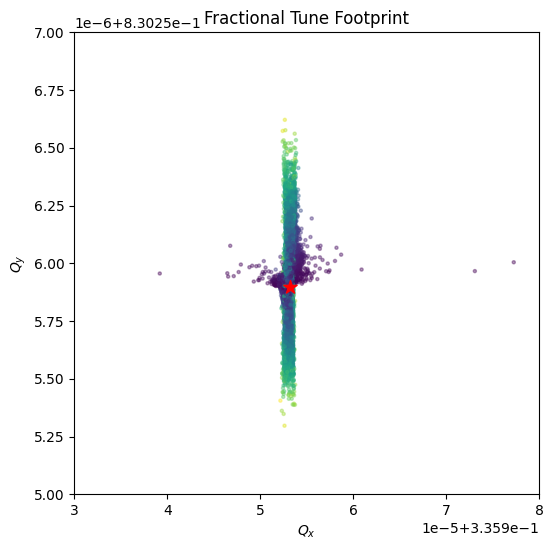

In [4]:
spreads = np.std(x_tbt, axis=1) # color code based on distance from a closed orbist
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(Qx, Qy, s=5, c=spreads, alpha=0.4)
ax.scatter(qx%1, qy%1, s=100, c='r', marker='*')

ax.set_xlim(0.33593,0.33598)
ax.set_ylim(5.5e-5+8.302e-1,5.7e-5+8.302e-1)
ax.set_xlabel('$Q_x$')
ax.set_ylabel('$Q_y$')
ax.set_title('Fractional Tune Footprint')

# With Space charge

In [2]:
name = 'longer_run'

with h5py.File(f'data/{name}.h5', 'r') as f:
    n_particles = f.attrs['n_particles']
    nemitt_x_0 = f.attrs['nemitt_x_0']
    nemitt_y_0 = f.attrs['nemitt_y_0']
    
    gamma = f.attrs['gamma']
    beta = f.attrs['beta']
    
    qx = f.attrs['qx']
    qy = f.attrs['qy']
    dqx = f.attrs['dqx']
    dqy = f.attrs['dqy']
    
    x_tbt = f['x_tbt'][:]
    y_tbt = f['y_tbt'][:]
    px_tbt = f['px_tbt'][:]
    py_tbt = f['py_tbt'][:]

    twiss = f['twiss_data']
    
df_twiss = pd.read_hdf(f'data/{name}.h5', key='twiss_data')

betx = df_twiss['betx'].values
bety = df_twiss['bety'].values
alfx = df_twiss['alfx'].values
alfy = df_twiss['alfy'].values

/home/rsimpson/anaconda3/envs/Xtrack/lib/python3.13/site-packages/tables/attributeset.py:322: DataTypeWarning: Unsupported type for attribute 'thick' in node '/'. Offending HDF5 class: 8
  value = self._g_getattr(self._v_node, name)


In [3]:
Qx = utils.get_tune(x_tbt, px_tbt, betx[0], alfx[0])
Qy = utils.get_tune(y_tbt, py_tbt, bety[0], alfy[0])

Qy = abs(Qy)
for i in range(len(Qy)):
    if Qy[i]>0.2:
        qy[i] = qy[i]/2
        
Qy = 1-Qy

nemitt_x_tbt = utils.calculate_emittance_tbt(x_tbt, px_tbt, beta, gamma)
nemitt_y_tbt = utils.calculate_emittance_tbt(y_tbt, py_tbt, beta, gamma)

Text(0.5, 1.0, 'Fractional Tune Footprint')

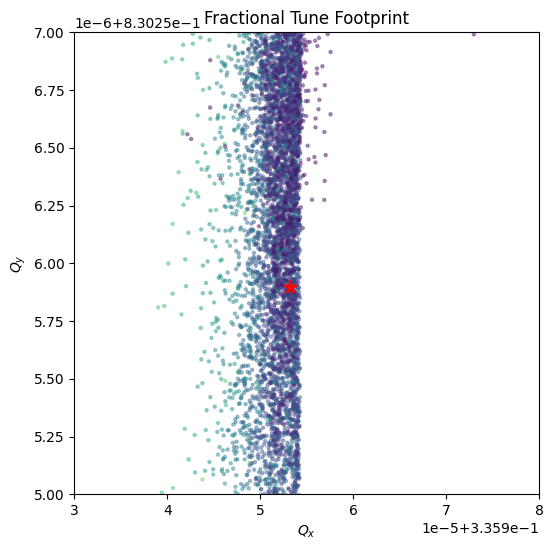

In [4]:
spreads = np.std(x_tbt, axis=1) # color code based on distance from a closed orbist
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(Qx, Qy, s=5, c=spreads, alpha=0.4)
ax.scatter(qx%1, qy%1, s=100, c='r', marker='*')

ax.set_xlim(0.33593,0.33598)
ax.set_ylim(5.5e-5+8.302e-1,5.7e-5+8.302e-1)
ax.set_xlabel('$Q_x$')
ax.set_ylabel('$Q_y$')
ax.set_title('Fractional Tune Footprint')

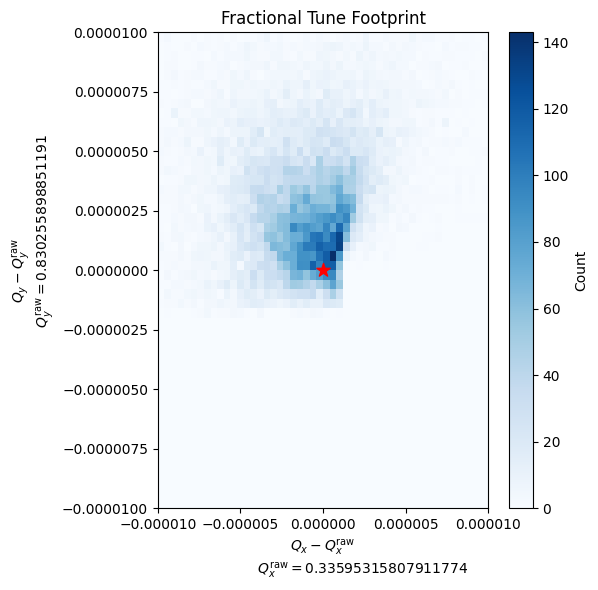

In [4]:
utils.plot_tunes(Qx, Qy, qx, qy)